Question 1

Processing first image...
ret found
(286, 1, 2)


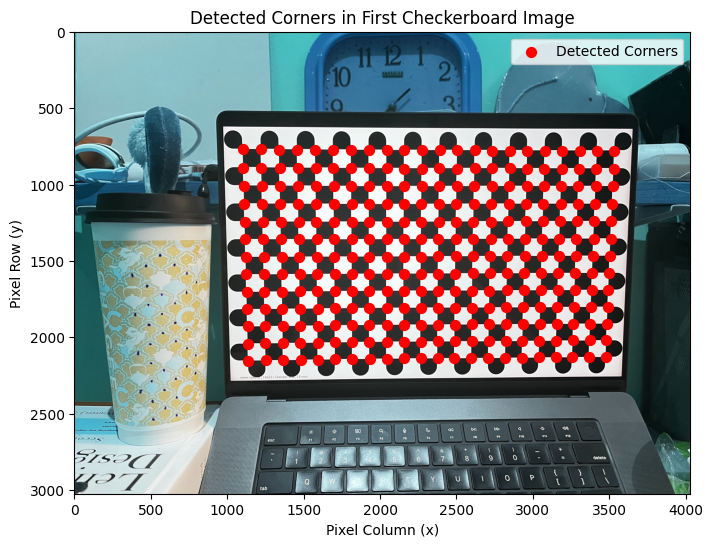

Corners successfully detected in the first image.

Processing all images...

Processing image 1: IMG_3471.jpeg
ret found
(286, 1, 2)
Successfully detected 286 corners in image 1.

Processing image 2: IMG_3472.jpeg
ret found
(286, 1, 2)
Successfully detected 286 corners in image 2.

Processing image 3: IMG_3473.jpeg
ret found
(286, 1, 2)
Successfully detected 286 corners in image 3.

Processing image 4: IMG_3474.jpeg
ret found
(286, 1, 2)
Successfully detected 286 corners in image 4.

Processing image 5: IMG_3475.jpeg
ret found
(286, 1, 2)
Successfully detected 286 corners in image 5.

Processing image 6: IMG_3476.jpeg
ret found
(286, 1, 2)
Successfully detected 286 corners in image 6.

Processing image 7: IMG_3477.jpeg
ret found
(286, 1, 2)
Successfully detected 286 corners in image 7.

Processing image 8: IMG_3478.jpeg
ret found
(286, 1, 2)
Successfully detected 286 corners in image 8.

Processing image 9: IMG_3479.jpeg
ret found
(286, 1, 2)
Successfully detected 286 corners in image 

In [50]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

# Define checkerboard size (number of inner corners per row and column)
CHECKERBOARD = (13, 22)  # Example: 14x23 inner corners

objp = np.zeros((13*22,3), np.float32)
objp[:,:2] = np.mgrid[0:13,0:22].T.reshape(-1,2)
# Arrays to store object points and image points from all the images.
objpoints = [] # 3d point in real world space
imgpoints = [] # 2d points in image plane.

# Directory containing the checkerboard images
DATA_DIR = "SelfCapture/Calibration/NoPattern"
image_files = sorted(glob.glob(os.path.join(DATA_DIR, "*.jpeg")))  # Adjust extension if needed

# Function to detect and plot corners
def detect_and_plot_corners(image_path, plot_title, save_path=None):
    # Load image
    img = cv2.imread(image_path)
    if img is None:
        print(f"Failed to load image: {image_path}")
        return False, None, img
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Detect checkerboard corners
    ret, corners=cv2.findChessboardCornersSB(gray, CHECKERBOARD, cv2.CALIB_CB_NORMALIZE_IMAGE,cv2.CALIB_CB_EXHAUSTIVE)

    if ret:
        print("ret found")
        objpoints.append(objp)
        # Refine corner positions
        corners = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1), 
            criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 3000, 0.001))
        print(corners.shape)
        imgpoints.append(corners)
        # Draw corners on image for visualization
        img_with_corners = img.copy()
        cv2.drawChessboardCorners(img_with_corners, CHECKERBOARD, corners, ret)

        # Plot corners in pixel coordinates
        plt.figure(figsize=(8, 6))
        plt.imshow(img, cmap='gray')
        corners = corners.squeeze()  # Shape: (N, 2)
        plt.scatter(corners[:, 0], corners[:, 1], c='red', s=50, label='Detected Corners')
        plt.title(plot_title)
        plt.xlabel('Pixel Column (x)')
        plt.ylabel('Pixel Row (y)')
        plt.legend()
        if save_path:
            plt.savefig(save_path)
            plt.close()
        else:
            plt.show()

        return True, corners, img_with_corners
    else:
        # Plot the image even if detection failed
        plt.figure(figsize=(8, 6))
        plt.imshow(img, cmap='gray')
        plt.title(f"{plot_title} (No Corners Detected)")
        plt.xlabel('Pixel Column (x)')
        plt.ylabel('Pixel Row (y)')
        if save_path:
            plt.savefig(save_path)
            plt.close()
        else:
            plt.show()
        return False, None, img

# Part a: Detect and plot corners for the first image
if image_files:
    print("Processing first image...")
    success, corners, _ = detect_and_plot_corners(
        image_files[0], 
        "Detected Corners in First Checkerboard Image"
    )
    if success:
        print("Corners successfully detected in the first image.")
    else:
        print("Failed to detect corners in the first image.")

# Part b: Detect corners in all 30 images and report failures
print("\nProcessing all images...")
failed_images = []
for i, img_path in enumerate(image_files[:35]):  # Limit to 30 images
    print(f"\nProcessing image {i+1}: {os.path.basename(img_path)}")
    save_path = f"SelfCapture/output/output_image_{i+1}.jpeg"
    success, corners, _ = detect_and_plot_corners(
        img_path, 
        f"Checkerboard Image {i+1}", 
        save_path=save_path
    )
    if not success:
        print(f"Failed to detect corners in image {i+1}: {os.path.basename(img_path)}")
        failed_images.append((i+1, img_path, save_path))
    else:
        print(f"Successfully detected {len(corners)} corners in image {i+1}.")

# Report summary
print("\nSummary:")
print(f"Processed {min(len(image_files), 30)} images.")
print(f"Number of images with failed corner detection: {len(failed_images)}")
if failed_images:
    print("Images with failed corner detection:")
    for idx, img_path, save_path in failed_images:
        print(f"Image {idx}: {os.path.basename(img_path)} (see {save_path})")
else:
    print("All corners successfully detected in all images.")

img = cv2.imread(image_files[0])
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
camera_width=img.shape[0]
camera_height=img.shape[1]
criteriaEnd = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30000, 0.0001)  # Termination criteria for estimateCameraParams
reprojectionError1, camera_matrix1, dist_coeffs1, rotation_vectors, translation_vectors = cv2.calibrateCamera(
    objpoints, imgpoints, (camera_width, camera_height), None, None,
    flags=cv2.CALIB_FIX_K4 + cv2.CALIB_FIX_K5 + cv2.CALIB_FIX_K6,criteria=criteriaEnd
)
print(reprojectionError1)

In [51]:
# undistord 
newcameramtx, roi = cv2.getOptimalNewCameraMatrix(camera_matrix1, 
                                                  dist_coeffs1, 
                                                  (camera_width,camera_height), 
                                                  1, 
                                                  (camera_width,camera_height)
                                                  )


Question 2

<Figure size 800x600 with 0 Axes>

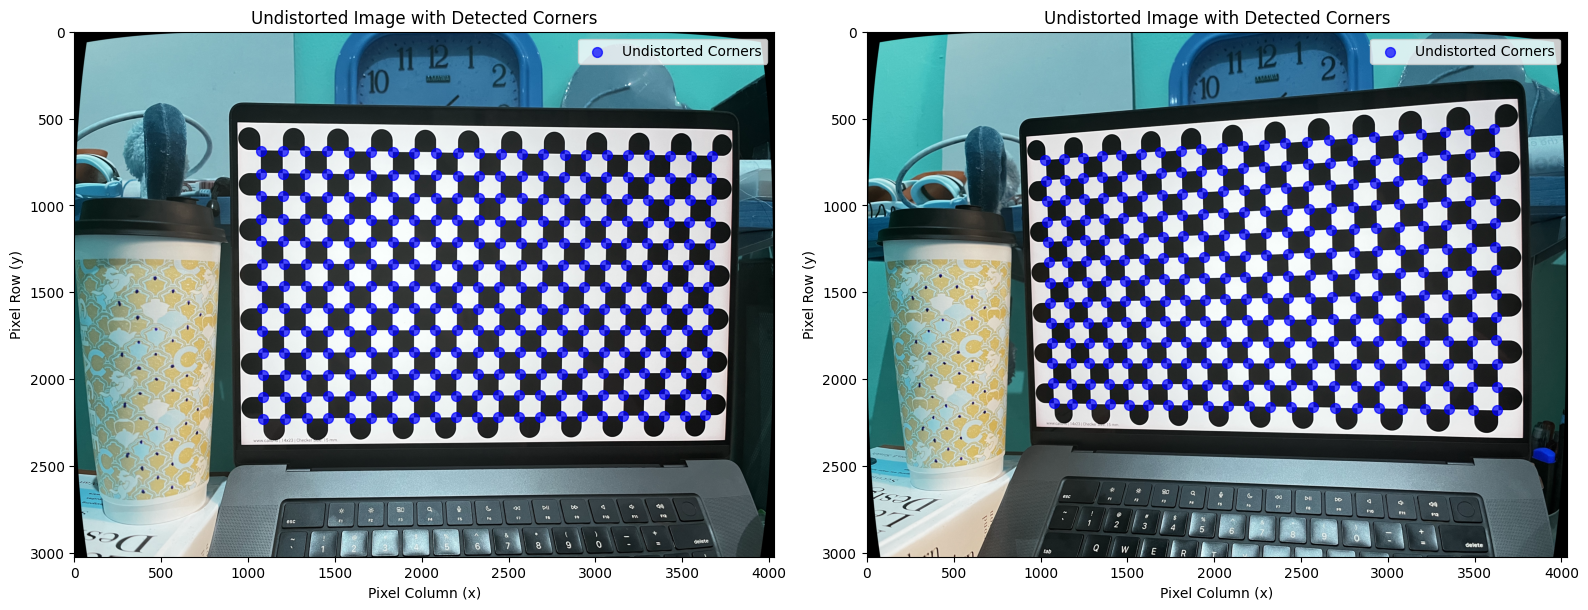

In [52]:
# load two undistorded images with custom feature points and calculate estrinsic 
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.0001)

# Load the image 1 
img = cv2.imread("SelfCapture/Cup/IMG_3498.jpeg")
# Undistort the image
un_dst_img = cv2.undistort(img, camera_matrix1, dist_coeffs1, None, newcameramtx)
# Convert undistorted image to grayscale for corner detection
un_dst_gray = cv2.cvtColor(un_dst_img, cv2.COLOR_BGR2GRAY)
# Detect corners in the undistorted image
ret, corners_undist = cv2.findChessboardCornersSB(
    un_dst_gray, CHECKERBOARD, 
    flags=cv2.CALIB_CB_NORMALIZE_IMAGE | cv2.CALIB_CB_EXHAUSTIVE
)
if ret:
    # Refine corners
    corners_undist = cv2.cornerSubPix(un_dst_gray, corners_undist, (11, 11), (-1, -1), criteria)
    plt.figure(figsize=(8, 6))
else:
    raise ValueError("Checkerboard corners not detected in undistorted image")

# Draw corners on image for visualization
# Create side-by-side plots
plt.figure(figsize=(16, 6))

# Left subplot: Original image with original corners
plt.subplot(1, 2, 1)
# Plot corners in pixel coordinates
plt.imshow(un_dst_img)
corners_undist = corners_undist.squeeze()  # Shape: (N, 2)
plt.scatter(corners_undist[:, 0], corners_undist[:, 1], c='blue', s=50, label='Undistorted Corners', alpha=0.7)
plt.title('Undistorted Image with Detected Corners')
plt.xlabel('Pixel Column (x)')
plt.ylabel('Pixel Row (y)')
plt.legend()

# Load the image 2
img_2 = cv2.imread("SelfCapture/Cup/IMG_3499.jpeg")
# Undistort the image
un_dst_img_2 = cv2.undistort(img_2, camera_matrix1, dist_coeffs1, None, newcameramtx)
# Convert undistorted image to grayscale for corner detection
un_dst_gray_2 = cv2.cvtColor(un_dst_img_2, cv2.COLOR_BGR2GRAY)
# Detect corners in the undistorted image
ret, corners_undist_2 = cv2.findChessboardCornersSB(
    un_dst_gray_2, CHECKERBOARD, 
    flags=cv2.CALIB_CB_NORMALIZE_IMAGE | cv2.CALIB_CB_EXHAUSTIVE
)
if ret:
    # Refine corners
    corners_undist_2 = cv2.cornerSubPix(un_dst_gray_2, corners_undist_2, (11, 11), (-1, -1), criteria)
else:
    raise ValueError("Checkerboard corners not detected in undistorted image")

# Draw corners on image for visualization
plt.subplot(1, 2, 2)
# Plot corners in pixel coordinates
plt.imshow(un_dst_img_2)
corners_undist_2 = corners_undist_2.squeeze()  # Shape: (N, 2)
plt.scatter(corners_undist_2[:, 0], corners_undist_2[:, 1], c='blue', s=50, label='Undistorted Corners', alpha=0.7)
plt.title('Undistorted Image with Detected Corners')
plt.xlabel('Pixel Column (x)')
plt.ylabel('Pixel Row (y)')
plt.legend()

# Adjust layout and display
plt.tight_layout()
plt.show()
plt.close()

show markers in both images

In [53]:
# we use thresholding for labeeling instead of label it manually
import cv2
import numpy as np

def detect_red_dots(image_filename):
    """
    Detect red dots in an image, label them from top-right to bottom-left, and return their center points.
    
    Args:
        image_filename (str): Path to the input image (e.g., 'image1.jpg').
    
    Returns:
        list: List of tuples (x, y) representing the center coordinates of detected dots.
    """
    # Load the image
    image = cv2.imread(image_filename)
    if image is None:
        raise ValueError(f"Could not load image: {image_filename}")

    # Convert to HSV color space
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # Define range for red color, including darker reds
    lower_red1 = np.array([0, 50, 20])    # Lower bound for red (near 0 hue)
    upper_red1 = np.array([10, 255, 255]) # Upper bound for red
    lower_red2 = np.array([170, 50, 20])  # Lower bound for red (near 180 hue)
    upper_red2 = np.array([190, 255, 255]) # Upper bound for red

    # Create masks for red color
    mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
    mask2 = cv2.inRange(hsv, lower_red2, upper_red2)
    mask = mask1 + mask2  # Combine both red ranges

    # Apply morphological operations to clean up the mask
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.erode(mask, kernel, iterations=1)  # Remove small noise
    mask = cv2.dilate(mask, kernel, iterations=1) # Close small gaps

    # Find contours of the red dots
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Get centers of contours and sort by y then x (top-left to bottom-right)
    min_area = 16  # Minimum area for a dot
    max_area = 400
    y_min = 750
    dot_centers = []
    for contour in contours:
        area = cv2.contourArea(contour)
        if area > min_area and area<max_area:
            (x, y), radius = cv2.minEnclosingCircle(contour)
            if y>y_min:
                dot_centers.append((int(x), int(y), radius))
    # Sort by y (ascending) then x (ascending)
    dot_centers.sort(key=lambda p: (p[1], -p[0]))

    # Draw contours and labels
    output_image = image.copy()
    for i, (x, y, radius) in enumerate(dot_centers):
        # Draw green circle around the dot
        cv2.circle(output_image, (x, y), int(radius), (0, 255, 0), 2)
        
        # Add larger label at top-right of the center
        label = f"Dot {i+1}"
        label_pos = (x + 5, y - 5)  # Top-right offset
        cv2.putText(output_image, label, label_pos, cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 255), 2, cv2.LINE_AA)

    # Save output image
    output_filename = image_filename.replace('.jpeg', '_detected.jpeg')
    cv2.imwrite(output_filename, output_image)

    # Return list of (x, y) coordinates
    return [(x, y) for x, y, _ in dot_centers]

# Example usage
if __name__ == "__main__":
    # Process multiple images
    image_files = ['SelfCapture/Cup/IMG_3498.jpeg', 'SelfCapture/Cup/IMG_3499.jpeg']
    points = detect_red_dots(image_files[0])
    print(f"Detected points in {points}:")
    points_2 = detect_red_dots(image_files[1])
    print(f"Detected points in {points_2}:")


Detected points in [(476, 1376), (581, 1449), (372, 1450), (669, 1511), (270, 1518), (737, 1578), (378, 1596), (663, 1649), (483, 1661), (578, 1724), (383, 1734), (480, 1800), (286, 1804), (576, 1867), (384, 1879), (660, 1919), (484, 1939), (577, 2000), (391, 2019), (658, 2053), (302, 2085), (722, 2106), (393, 2159), (655, 2186), (487, 2213), (717, 2238), (570, 2275), (396, 2292), (485, 2356), (317, 2367), (576, 2413), (399, 2439), (490, 2488), (572, 2542), (403, 2570)]:
Detected points in [(433, 1362), (528, 1424), (349, 1428), (614, 1479), (273, 1486), (687, 1540), (357, 1553), (612, 1600), (447, 1610), (533, 1664), (366, 1672), (448, 1730), (293, 1731), (535, 1789), (370, 1796), (617, 1838), (454, 1850), (540, 1906), (380, 1919), (620, 1955), (313, 1974), (687, 2005), (386, 2040), (620, 2071), (466, 2089), (688, 2122), (542, 2147), (392, 2154), (468, 2213), (331, 2216), (551, 2268), (398, 2282), (476, 2330), (551, 2382), (403, 2397)]:


# calculate P extrinsic matrix for both images

In [81]:
import cv2
# Intrinsic parameters
K = camera_matrix1  # Ensure this is defined
dist_coeffs = np.zeros((5, 1), dtype=np.float32)

# Chessboard corners: 2D pixel coordinates
img_points1 = np.array(corners_undist)  # Shape: (286, 2)
img_points2 = np.array(corners_undist_2)  # Shape: (286, 2)

# Unsqueeze to (N, 1, 2)
img_points1 = np.expand_dims(img_points1, axis=1)  # Shape: (286, 1, 2)
img_points2 = np.expand_dims(img_points2, axis=1)  # Shape: (286, 1, 2)

print("img_points1 shape:", img_points1.shape)
print("img_points2 shape:", img_points2.shape)

# Check differences
diff = np.abs(img_points1 - img_points2)
print("Maximum difference between img_points1 and img_points2:", np.max(diff))

# Define checkerboard (13x22)
CHECKERBOARD = (13, 22)
square_size = 15.0  # mm
obj_points = np.zeros((CHECKERBOARD[0] * CHECKERBOARD[1], 3), np.float32)
obj_points[:, :2] = np.mgrid[0:CHECKERBOARD[0], 0:CHECKERBOARD[1]].T.reshape(-1, 2) * square_size
obj_points_h = cv2.convertPointsToHomogeneous(obj_points)[:, 0, :]  # Shape: (286, 4)

# Validate point counts
if img_points1.shape[0] != obj_points.shape[0]:
    raise ValueError(f"img_points1 has {img_points1.shape[0]} points, but obj_points has {obj_points.shape[0]} points")


def dlt_projection_matrix(obj_points_h, img_points, K):
    # Handle img_points shape
    if len(img_points.shape) == 2 and img_points.shape[-1] == 2:
        img_points = img_points.reshape(-1, 1, 2)
    elif img_points.shape[-2:] != (1, 2):
        raise ValueError(f"img_points must have shape (N, 1, 2) or (N, 2), got {img_points.shape}")
    
    if img_points.shape[0] != obj_points_h.shape[0]:
        raise ValueError(f"img_points has {img_points.shape[0]} points, but obj_points_h has {obj_points_h.shape[0]} points")
    
    # Convert to homogeneous coordinates
    img_points_h = cv2.convertPointsToHomogeneous(img_points)[:, 0, :]  # Shape: (N, 3)
    norm_points = (np.linalg.inv(K) @ img_points_h.T).T  # Shape: (N, 3)
    
    # Debug
    print("img_points_h shape:", img_points_h.shape)
    print("norm_points shape:", norm_points.shape)
    print("Sample norm_points:", norm_points[:5])
    
    # Build the DLT matrix A
    A = []
    for (X, Y, Z, W), (x, y, w) in zip(obj_points_h, norm_points):
        A.append([X, Y, Z, W, 0, 0, 0, 0, -x*X, -x*Y, -x*Z, -x*W])
        A.append([0, 0, 0, 0, X, Y, Z, W, -y*X, -y*Y, -y*Z, -y*W])
    A = np.array(A)  # Shape: (2N, 12)
    
    # Solve using SVD
    _, _, Vh = np.linalg.svd(A)
    P = Vh[-1].reshape(3, 4)
    
    # Extract R, t without over-normalization
    Rt = np.linalg.inv(K) @ P
    R = Rt[:, :3]
    t = Rt[:, 3]
    
    # Orthogonalize R
    U, _, Vt = np.linalg.svd(R)
    R = U @ Vt
    if np.linalg.det(R) < 0:
        R = -R
        t = -t
    
    # Scale translation (optional, based on checkerboard size)
    scale = np.linalg.norm(t)
    if scale > 0:
        t = t / scale * square_size  # Scale to match physical units (mm)
    
    return R, t.reshape(3, 1)

# Estimate extrinsics using DLT
R1_dlt, t1_dlt = dlt_projection_matrix(obj_points_h, img_points1, K)
R2_dlt, t2_dlt = dlt_projection_matrix(obj_points_h, img_points2, K)

print("R1 (DLT) shape:", R1_dlt.shape)
print("R1 (DLT):", R1_dlt)
print("t1 (DLT) shape:", t1_dlt.shape)
print("t1 (DLT):", t1_dlt)
print("R2 (DLT) shape:", R2_dlt.shape)
print("R2 (DLT):", R2_dlt)
print("t2 (DLT) shape:", t2_dlt.shape)
print("t2 (DLT):", t2_dlt)

# Check equality
if np.array_equal(R1_dlt, R2_dlt):
    print("R1 and R2 (DLT) are exactly equal")
else:
    print("R1 and R2 (DLT) are not exactly equal")

# Compare with PnP
success1, rvec1, tvec1 = cv2.solvePnP(obj_points, img_points1, K, dist_coeffs)
success2, rvec2, tvec2 = cv2.solvePnP(obj_points, img_points2, K, dist_coeffs)
R1_pnp, _ = cv2.Rodrigues(rvec1)
R2_pnp, _ = cv2.Rodrigues(rvec2)

print("R1 (PnP):", R1_pnp)
print("t1 (PnP):", tvec1)
print("R2 (PnP):", R2_pnp)
print("t2 (PnP):", tvec2)

# Compute relative pose (using PnP for reliability)
R = R2_pnp @ R1_pnp.T
t = tvec2 - R @ tvec1

# Set up projection matrices
P1 = K @ np.hstack((np.eye(3), np.zeros((3, 1))))
P2 = K @ np.hstack((R, t.reshape(3, 1)))

img_points1 shape: (286, 1, 2)
img_points2 shape: (286, 1, 2)
Maximum difference between img_points1 and img_points2: 169.19019
img_points_h shape: (286, 3)
norm_points shape: (286, 3)
Sample norm_points: [[-0.30290274  0.24158843  1.        ]
 [-0.3034381   0.20055771  1.        ]
 [-0.30390444  0.15946198  1.        ]
 [-0.30436213  0.11812114  1.        ]
 [-0.3048008   0.07658626  1.        ]]
img_points_h shape: (286, 3)
norm_points shape: (286, 3)
Sample norm_points: [[-0.30685134  0.21289479  1.        ]
 [-0.30816414  0.17534284  1.        ]
 [-0.30952962  0.13778926  1.        ]
 [-0.3108369   0.10007831  1.        ]
 [-0.31216022  0.06229748  1.        ]]
R1 (DLT) shape: (3, 3)
R1 (DLT): [[ 0.01115519  0.86073586  0.50892961]
 [ 0.89728279 -0.23324284  0.37480845]
 [ 0.44131526  0.45247272 -0.77492534]]
t1 (DLT) shape: (3, 1)
t1 (DLT): [[0.]
 [0.]
 [0.]]
R2 (DLT) shape: (3, 3)
R2 (DLT): [[ 0.01115519  0.86073586  0.50892961]
 [ 0.89728279 -0.23324284  0.37480845]
 [ 0.4413152

world_points shape: (286, 3)
checker_points shape: (286, 3)
R shape: (3, 3)
T shape: (3, 1)


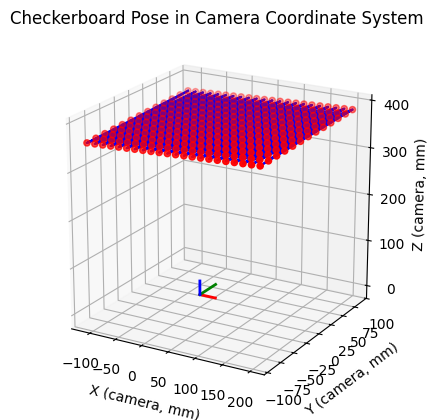

checker_points shape: (286, 3)
R shape: (3, 3)
T shape: (3, 1)


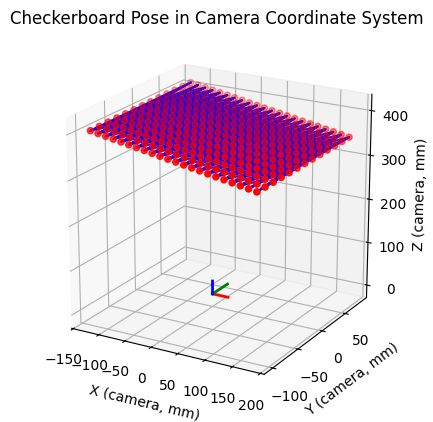

In [82]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

def generate_checkerboard_points(board_size, square_size):
    """
    Generate 3D points for a checkerboard in object coordinates.

    Parameters:
    - board_size: Tuple (rows, cols) of inner corners (e.g., (6, 8) for 7x9 checkerboard)
    - square_size: Size of each square in mm (e.g., 15)

    Returns:
    - objp: np.ndarray of shape (rows * cols, 3) with 3D points
    """
    if not isinstance(board_size, tuple) or len(board_size) != 2:
        raise ValueError("board_size must be a tuple of (rows, cols)")
    objp = np.zeros((board_size[0] * board_size[1], 3), np.float32)
    objp[:, :2] = np.mgrid[0:board_size[0], 0:board_size[1]].T.reshape(-1, 2)
    return objp * square_size

def showExtrinsics(checker_points, rvec, tvec, board_size):
    """
    Visualizes checkerboard pose in 3D using extrinsic parameters.

    Parameters:
    - checker_points: np.ndarray of shape (N, 3), 3D checkerboard points in object coordinates
    - rvec: Rotation vector (3, 1) from cv2.calibrateCamera or cv2.solvePnP
    - tvec: Translation vector (3, 1) from cv2.calibrateCamera or cv2.solvePnP
    - board_size: Tuple (rows, cols) of inner corners
    """
    # Validate inputs
    if checker_points.shape[1] != 3:
        raise ValueError(f"checker_points must have shape (N, 3), got {checker_points.shape}")
    # if rvec.shape != (3,) and rvec.shape != (3, 1):
    #     raise ValueError(f"rvec must be a 3-element vector, got shape {rvec.shape}")
    # if tvec.shape != (3,) and tvec.shape != (3, 1):
    #     raise ValueError(f"tvec must be a 3-element vector, got shape {tvec.shape}")

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    # Convert rotation vector to rotation matrix
    R = rvec
    T = tvec

    # Debug shapes
    print("checker_points shape:", checker_points.shape)
    print("R shape:", R.shape)
    print("T shape:", T.shape)

    # Transform the object points to the camera coordinate system
    transformed_points = (R @ checker_points.T + T).T  # shape (N, 3)

    # Reshape points into a grid for plotting
    rows, cols = board_size
    grid_points = transformed_points.reshape(rows, cols, 3)

    # Plot the checkerboard grid
    for i in range(rows):
        ax.plot(grid_points[i, :, 0], grid_points[i, :, 1], grid_points[i, :, 2], 'b-')  # Rows
    for j in range(cols):
        ax.plot(grid_points[:, j, 0], grid_points[:, j, 1], grid_points[:, j, 2], 'b-')  # Columns

    # Plot corner points
    ax.scatter(transformed_points[:, 0], transformed_points[:, 1], transformed_points[:, 2], c='r', s=20)

    # Plot camera coordinate axes at the camera position
    axis_length = square_size * 2
    origin = np.zeros((1, 3))
    axes = np.array([[axis_length, 0, 0], [0, axis_length, 0], [0, 0, axis_length]])
    for axis, color in zip(axes, ['r', 'g', 'b']):
        ax.plot([origin[0, 0], axis[0]], [origin[0, 1], axis[1]], [origin[0, 2], axis[2]], color, linewidth=2)

    ax.set_xlabel('X (camera, mm)')
    ax.set_ylabel('Y (camera, mm)')
    ax.set_zlabel('Z (camera, mm)')
    ax.set_title('Checkerboard Pose in Camera Coordinate System')
    ax.view_init(elev=20, azim=-60)
    ax.set_box_aspect([1, 1, 1])
    plt.grid(True)
    plt.show()

# Example usage
square_size = 15  # 15 mm

# Generate checkerboard points
world_points = generate_checkerboard_points(CHECKERBOARD, square_size)
print("world_points shape:", world_points.shape)

# Visualize
showExtrinsics(world_points, R1_pnp, tvec1, CHECKERBOARD)
showExtrinsics(world_points, R2_pnp, tvec2, CHECKERBOARD)

Question 3

In [84]:
# use undistorded image to perfome triangulation using PnP method
import cv2
import numpy as np

K = camera_matrix1
dist_coeffs = np.zeros((5, 1), dtype=np.float32)
# dist_coeffs = dist_coeffs1

# Chessboard corners: 2D pixel coordinates (from both images)
img_points1 = np.array(corners_undist) # Shape: (N, 2)
img_points2 = np.array(corners_undist_2)  # Shape: (N, 2)

# Unsqueeze to (N, 1, 2)
img_points1 = np.expand_dims(img_points1, axis=1)  # Shape: (286, 1, 2)
img_points2 = np.expand_dims(img_points2, axis=1)  # Shape: (286, 1, 2)
print(img_points1.shape)
print(img_points2.shape)

# Additional marker pixel coordinates (N markers)
marker_points1 = np.array(points, dtype=np.float32)  # Image 1
marker_points2 = np.array(points_2, dtype=np.float32)  # Image 2

# Step 1: Estimate camera poses using PnP
success1, rvec1, tvec1 = cv2.solvePnP(obj_points, img_points1, K, dist_coeffs)
success2, rvec2, tvec2 = cv2.solvePnP(obj_points, img_points2, K, dist_coeffs)

# Convert rotation vectors to matrices
R1, _ = cv2.Rodrigues(rvec1)
R2, _ = cv2.Rodrigues(rvec2)

# Check exact equality
if np.array_equal(R1, R2):
    print("R1 and R2 are exactly equal")
else:
    print("R1 and R2 are not exactly equal")

# Step 2: Compute relative pose
R = R2 @ R1.T
t = tvec2 - R @ tvec1

# Step 3: Set up projection matrices
P1 = K @ np.hstack((np.eye(3), np.zeros((3, 1))))  # Camera 1: [K | 0]
P2 = K @ np.hstack((R, t.reshape(3, 1)))           # Camera 2: [K | R, t]


# Step 4: Triangulate marker points
points1_2d = marker_points1.T  # Shape: (2, M)
points2_2d = marker_points2.T  # Shape: (2, M)
points_4d = cv2.triangulatePoints(P1, P2, points1_2d, points2_2d)  # Shape: (4, M)
points_3d = points_4d[:3] / points_4d[3]  # Normalize to Cartesian coordinates
points_3d = points_3d.T  # Shape: (N, 3), in camera 1 coordinates (mm)

# Step 5: Transform to world coordinate system (optional)
R1_inv = R1.T
t1_inv = -R1_inv @ tvec1
points_3d_world = (R1_inv @ points_3d.T + t1_inv).T  # Shape: (N, 3)

print("Reconstructed 3D points shape:\n", points_3d_world.shape)
print("Reconstructed 3D points (world coordinates, mm):\n", points_3d_world)

# Step 6: Verify reprojection error
proj_points1, _ = cv2.projectPoints(points_3d_world, rvec1, tvec1, K, dist_coeffs)
proj_points2, _ = cv2.projectPoints(points_3d_world, rvec2, tvec2, K, dist_coeffs)
reproj_error1 = np.mean(np.linalg.norm(proj_points1[:, 0, :] - marker_points1, axis=1))
reproj_error2 = np.mean(np.linalg.norm(proj_points2[:, 0, :] - marker_points2, axis=1))
print("Reprojection error (pixels): Image 1 =", reproj_error1, "Image 2 =", reproj_error2)

(286, 1, 2)
(286, 1, 2)
R1 and R2 are not exactly equal
Reconstructed 3D points shape:
 (35, 3)
Reconstructed 3D points (world coordinates, mm):
 [[100.81029955 -38.7546215  -66.40587221]
 [ 93.63721346 -31.38456369 -60.61190113]
 [ 93.71497268 -46.86670956 -70.00680633]
 [ 87.14607515 -25.70857216 -53.56616554]
 [ 87.40343242 -55.52797962 -71.59218438]
 [ 79.75682458 -21.89250168 -45.77948529]
 [ 79.78827176 -46.6082546  -69.86680688]
 [ 73.20717682 -26.37666277 -53.83357741]
 [ 73.08073712 -38.92737146 -65.48962461]
 [ 66.40070931 -32.19254079 -60.26968566]
 [ 66.45861309 -46.76143584 -69.01562774]
 [ 59.55276934 -39.41965427 -65.47270306]
 [ 60.04642288 -54.98292011 -70.71942062]
 [ 52.15595183 -32.6211669  -60.18122036]
 [ 52.52777541 -46.89316552 -69.01387881]
 [ 45.65594916 -27.19122759 -53.41863514]
 [ 45.99207332 -39.22850192 -65.51460966]
 [ 38.74521567 -32.91270043 -59.6963987 ]
 [ 38.71254277 -46.82120557 -68.27340955]
 [ 31.9015081  -27.76087009 -52.89423076]
 [ 32.72625442

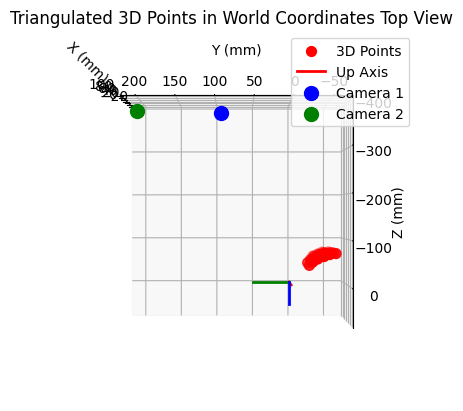

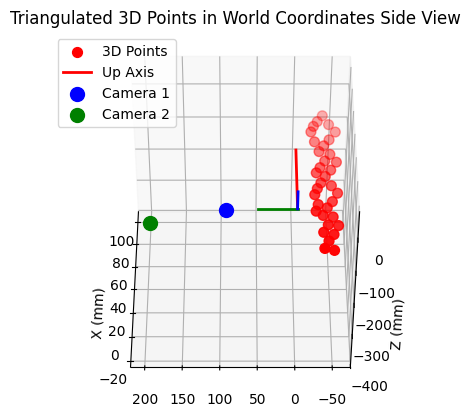

In [138]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_3d_points(points_3d, R1, tvec1, R2, tvec2, title="Triangulated 3D Points", elev=180, azim=180):
    """
    Plots triangulated 3D points in world coordinates with camera positions and axes.

    Parameters:
    - points_3d: np.ndarray of shape (N, 3), 3D points in world coordinates (mm)
    - R1, R2: Rotation matrices (3, 3) for cameras 1 and 2
    - tvec1, tvec2: Translation vectors (3, 1) for cameras 1 and 2 in camera coordinates
    - title: Plot title
    """
    # Create 3D plot
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    # Plot 3D points as red scatter
    ax.scatter(points_3d[:, 0], points_3d[:, 1], points_3d[:, 2], c='r', s=50, label='3D Points')

    # Plot world coordinate axes
    axis_length = 50.0  # mm, adjust based on point scale
    origin = np.zeros((1, 3))
    axes = np.array([[axis_length, 0, 0], [0, axis_length, 0], [0, 0, axis_length]])
    for axis, color in zip(axes, ['r', 'g', 'b']):
        ax.plot([origin[0, 0], axis[0]], [origin[0, 1], axis[1]], [origin[0, 2], axis[2]], 
                color, linewidth=2, label=f'Up Axis' if color == 'r' else '')

    # Transform camera positions to world coordinates
    R1_inv = R1.T
    t1_world = -R1_inv @ tvec1  # Camera 1 position in world coordinates
    R2_inv = R2.T
    t2_world = -R2_inv @ tvec2  # Camera 2 position in world coordinates

    # Plot camera positions as blue and green scatter points
    ax.scatter(t1_world[0], t1_world[1], t1_world[2], c='b', s=100, marker='o', label='Camera 1')
    ax.scatter(t2_world[0], t2_world[1], t2_world[2], c='g', s=100, marker='o', label='Camera 2')

    # # Plot camera orientation axes (optional, for visualization)
    # cam_axis_length = 20.0  # mm
    # for R, t, color, name in [(R1_inv, t1_world, 'b', 'Cam1'), (R2_inv, t2_world, 'g', 'Cam2')]:
    #     cam_axes = np.array([[cam_axis_length, 0, 0], [0, cam_axis_length, 0], [0, 0, cam_axis_length]])
    #     cam_axes_world = (R @ cam_axes.T + t).T  # Transform to world coordinates
    #     for axis, ax_color in zip(cam_axes_world, ['r', 'g', 'b']):
    #         ax.plot([t[0], axis[0]], [t[1], axis[1]], [t[2], axis[2]], ax_color, linewidth=1)

    # Set plot properties
    ax.set_xlabel('X (mm)')
    ax.set_ylabel('Y (mm)')
    ax.set_zlabel('Z (mm)')
    ax.set_title(title)
    ax.view_init(elev=elev, azim=azim)
    ax.set_box_aspect([1, 1, 1])
    ax.grid(True)
    ax.legend()

    plt.show()

# Step 7: Plot the 3D points
plot_3d_points(points_3d_world, R1, tvec1, R2, tvec2, title="Triangulated 3D Points in World Coordinates Top View", elev=180, azim=180)
plot_3d_points(points_3d_world, R1, tvec1, R2, tvec2, title="Triangulated 3D Points in World Coordinates Side View", elev=45, azim=180)

Export point cloud as glb for question 5

In [139]:
def save_ply(points, filename="point_cloud.ply"):
    """
    Saves 3D points to a PLY file in ASCII format.

    Parameters:
    - points: np.ndarray of shape (N, 3), 3D points with X, Y, Z coordinates (mm)
    - filename: Output PLY file path
    """
    num_points = points.shape[0]

    # Write PLY header
    header = f"""ply
format ascii 1.0
element vertex {num_points}
property float x
property float y
property float z
end_header
"""

    # Write points
    with open(filename, 'w') as f:
        f.write(header)
        for point in points:
            f.write(f"{point[0]} {point[1]} {point[2]}\n")

    print(f"PLY file saved to {filename}")

save_ply(points_3d_world, filename="point_cloud.ply")

PLY file saved to point_cloud.ply
